# Pricing Options via Feynman-Kac and Monte Carlo

## From PDE to Expectation

In Chapter 3, we saw the Feynman-Kac formula links PDEs to stochastic expectations. The **Black-Scholes PDE** is a perfect application:

$$\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} - rV = 0$$

with terminal condition $V(S, T) = \text{payoff}(S_T)$.

This is exactly the Feynman-Kac form with:
- Drift: $\mu(S) = rS$ (risk-neutral drift)
- Diffusion: $\sigma(S) = \sigma S$
- Potential: $V = r$ (the discount rate)
- Terminal: $\psi(S) = \text{payoff}(S_T)$

The Feynman-Kac solution gives the **risk-neutral pricing formula**:

$$V(S, t) = e^{-r(T-t)} \, \mathbb{E}\!\left[\text{payoff}(S_T) \;\middle|\; S_t = S\right]$$

where $S_T$ follows the risk-neutral geometric Brownian motion:

$$S_T = S_0 \exp\!\left[\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\,Z\right], \quad Z \sim N(0, 1)$$

The power of this approach: it works for **any** payoff function — not just vanilla calls and puts. We can price digital options, barrier options, straddles, or any exotic payoff by simply changing the payoff function.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, log, sqrt, exp, pi
%matplotlib inline

# Black-Scholes analytical formulas for reference
def bs_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def bs_call(S, K, r, T, sigma):
    d1 = (log(S/K) + (r + sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return S * bs_cdf(d1) - K * exp(-r*T) * bs_cdf(d2)

def bs_put(S, K, r, T, sigma):
    d1 = (log(S/K) + (r + sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return -S * bs_cdf(-d1) + K * exp(-r*T) * bs_cdf(-d2)

def bs_digital_call(S, K, r, T, sigma):
    """Digital call pays 1 if S_T > K, 0 otherwise."""
    d2 = (log(S/K) + (r - sigma**2/2)*T) / (sigma*sqrt(T))
    return exp(-r*T) * bs_cdf(d2)

## The Monte Carlo Engine

The Feynman-Kac pricing formula $V = e^{-rT}\,\mathbb{E}[\text{payoff}(S_T)]$ is remarkably simple to implement:

1. **Simulate** many terminal asset prices $S_T$ under the risk-neutral measure
2. **Evaluate** the payoff for each path
3. **Average** and discount back to today

The key insight: we only need to change the payoff function to price any European-style derivative. The simulation engine stays the same.

In [2]:
def mc_price(payoff, S0, r, T, sigma, n_paths=500000):
    """
    Feynman-Kac Monte Carlo pricer for European options.
    
    payoff: function of S_T -> payoff value
    S0: initial asset price
    r: risk-free rate
    T: time to expiration
    sigma: volatility
    n_paths: number of MC paths
    
    Returns: (price, std_error)
    """
    Z = np.random.randn(n_paths)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = payoff(S_T)
    discounted = np.exp(-r * T) * payoffs
    price = np.mean(discounted)
    std_err = np.std(discounted) / np.sqrt(n_paths)
    return price, std_err

## 1. Vanilla European Options

Let's verify the MC pricer against the analytical Black-Scholes formula.

In [3]:
# Parameters
S0, K, r, T, sigma = 100, 100, 0.05, 1.0, 0.2

# Analytical prices
call_bs = bs_call(S0, K, r, T, sigma)
put_bs = bs_put(S0, K, r, T, sigma)

# Monte Carlo prices via Feynman-Kac
call_mc, call_err = mc_price(lambda S: np.maximum(S - K, 0), S0, r, T, sigma)
put_mc, put_err = mc_price(lambda S: np.maximum(K - S, 0), S0, r, T, sigma)

print("=== European Vanilla Options ===")
print(f"{'':15s} {'BS Analytical':>14s} {'MC (Feynman-Kac)':>18s} {'Std Error':>10s}")
print(f"{'Call':15s} {call_bs:14.6f} {call_mc:18.6f} {call_err:10.6f}")
print(f"{'Put':15s} {put_bs:14.6f} {put_mc:18.6f} {put_err:10.6f}")

=== European Vanilla Options ===
                 BS Analytical   MC (Feynman-Kac)  Std Error
Call                 10.450584          10.443412   0.020802
Put                   5.573526           5.577734   0.012241


## 2. Digital (Binary) Option

A digital call pays $1 if $S_T > K$, and $0$ otherwise. Its analytical price under Black-Scholes is $e^{-rT}\Phi(d_2)$.

With Feynman-Kac, we just swap the payoff function — no new theory needed.

In [4]:
digital_bs = bs_digital_call(S0, K, r, T, sigma)
digital_mc, digital_err = mc_price(lambda S: (S > K).astype(float), S0, r, T, sigma)

print("=== Digital Call Option ===")
print(f"BS Analytical:    {digital_bs:.6f}")
print(f"MC (Feynman-Kac): {digital_mc:.6f} +/- {digital_err:.6f}")

=== Digital Call Option ===
BS Analytical:    0.532325
MC (Feynman-Kac): 0.532926 +/- 0.000668


## 3. Exotic Payoffs — No Closed-Form Needed

This is where Feynman-Kac truly shines. For complex payoffs with no analytical solution, the MC pricer works unchanged. We demonstrate with:

- **Straddle**: $|S_T - K|$ (long call + long put at same strike)
- **Power option**: $\max(S_T^2 / S_0 - K, 0)$ (payoff based on squared return)
- **Capped call**: $\min(\max(S_T - K, 0), \text{cap})$ (call with capped upside)

In [5]:
cap = 20  # cap for capped call

# Straddle: can verify as call + put
straddle_bs = call_bs + put_bs
straddle_mc, straddle_err = mc_price(lambda S: np.abs(S - K), S0, r, T, sigma)

# Power option: no simple closed-form
power_mc, power_err = mc_price(lambda S: np.maximum(S**2 / S0 - K, 0), S0, r, T, sigma)

# Capped call
capped_mc, capped_err = mc_price(lambda S: np.minimum(np.maximum(S - K, 0), cap), S0, r, T, sigma)

print("=== Exotic European Options ===")
print(f"{'':15s} {'Reference':>14s} {'MC (Feynman-Kac)':>18s} {'Std Error':>10s}")
print(f"{'Straddle':15s} {straddle_bs:14.6f} {straddle_mc:18.6f} {straddle_err:10.6f}")
print(f"{'Power call':15s} {'N/A':>14s} {power_mc:18.6f} {power_err:10.6f}")
print(f"{'Capped call':15s} {'N/A':>14s} {capped_mc:18.6f} {capped_err:10.6f}")

=== Exotic European Options ===
                     Reference   MC (Feynman-Kac)  Std Error
Straddle             16.024110          16.011161   0.018673
Power call                 N/A          24.378694   0.052232
Capped call                N/A           7.196686   0.011369


## 4. Convergence and Payoff Visualization

Let's visualize the payoff functions and how the MC estimate converges as we increase the number of paths.

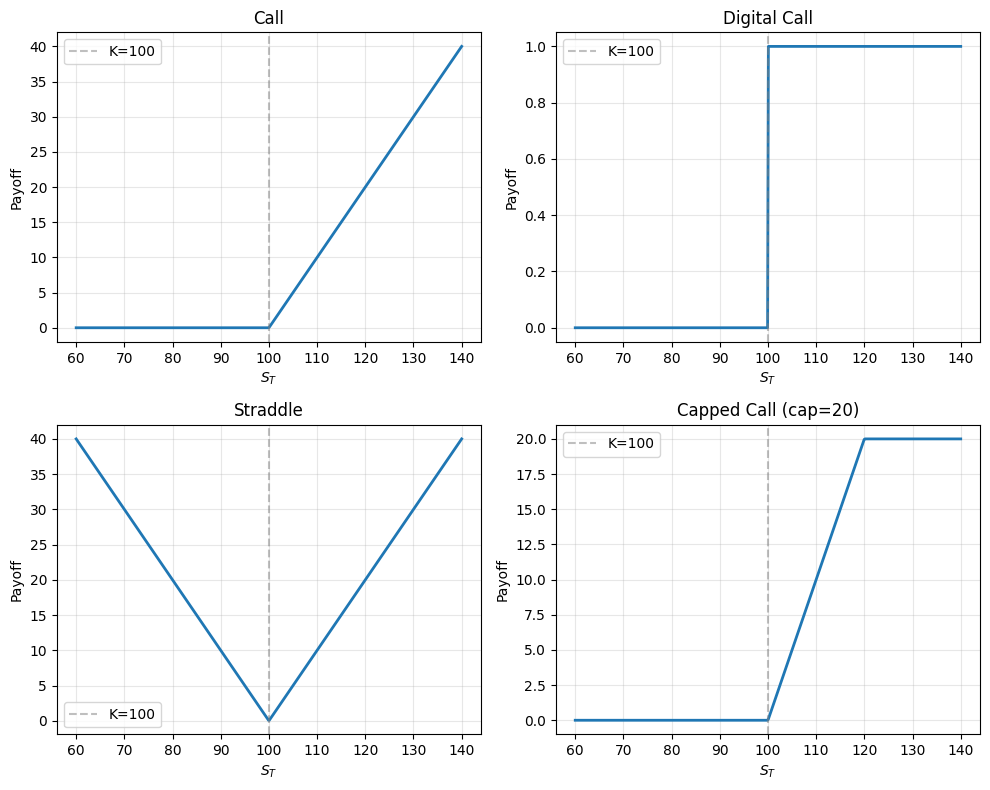

In [6]:
# Plot payoff functions
S_range = np.linspace(60, 140, 500)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

payoffs = [
    ("Call", lambda S: np.maximum(S - K, 0)),
    ("Digital Call", lambda S: (S > K).astype(float)),
    ("Straddle", lambda S: np.abs(S - K)),
    ("Capped Call (cap=20)", lambda S: np.minimum(np.maximum(S - K, 0), cap)),
]

for ax, (name, payoff) in zip(axes.flatten(), payoffs):
    ax.plot(S_range, payoff(S_range), linewidth=2)
    ax.axvline(K, color='gray', linestyle='--', alpha=0.5, label=f'K={K}')
    ax.set_xlabel('$S_T$')
    ax.set_ylabel('Payoff')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

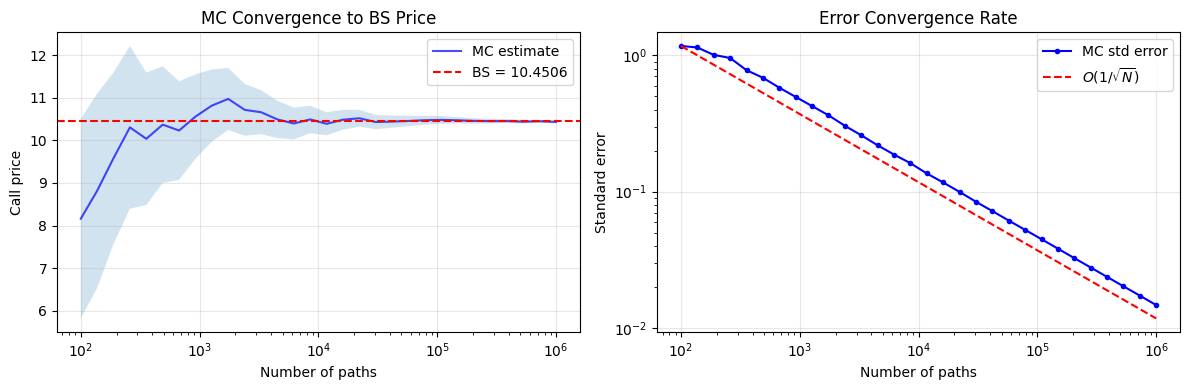

In [7]:
# Convergence plot: MC call price vs number of paths
np.random.seed(42)
path_counts = np.logspace(2, 6, 30).astype(int)
mc_prices = []
mc_errors = []

# Generate all random numbers at once for consistency
Z_all = np.random.randn(path_counts[-1])

for n in path_counts:
    Z = Z_all[:n]
    S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoffs = np.maximum(S_T - K, 0)
    disc = np.exp(-r*T) * payoffs
    mc_prices.append(np.mean(disc))
    mc_errors.append(np.std(disc) / np.sqrt(n))

mc_prices = np.array(mc_prices)
mc_errors = np.array(mc_errors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Price convergence
ax1.semilogx(path_counts, mc_prices, 'b-', alpha=0.7, label='MC estimate')
ax1.fill_between(path_counts, mc_prices - 2*mc_errors, mc_prices + 2*mc_errors, alpha=0.2)
ax1.axhline(call_bs, color='r', linestyle='--', label=f'BS = {call_bs:.4f}')
ax1.set_xlabel('Number of paths')
ax1.set_ylabel('Call price')
ax1.set_title('MC Convergence to BS Price')
ax1.legend()
ax1.grid(alpha=0.3)

# Standard error decay
ax2.loglog(path_counts, mc_errors, 'b-o', markersize=3, label='MC std error')
ax2.loglog(path_counts, mc_errors[0]*np.sqrt(path_counts[0]/path_counts), 'r--', label=r'$O(1/\sqrt{N})$')
ax2.set_xlabel('Number of paths')
ax2.set_ylabel('Standard error')
ax2.set_title('Error Convergence Rate')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Price Surface: Varying $S_0$ and $\sigma$

The Feynman-Kac pricer can easily sweep parameters to build price surfaces.

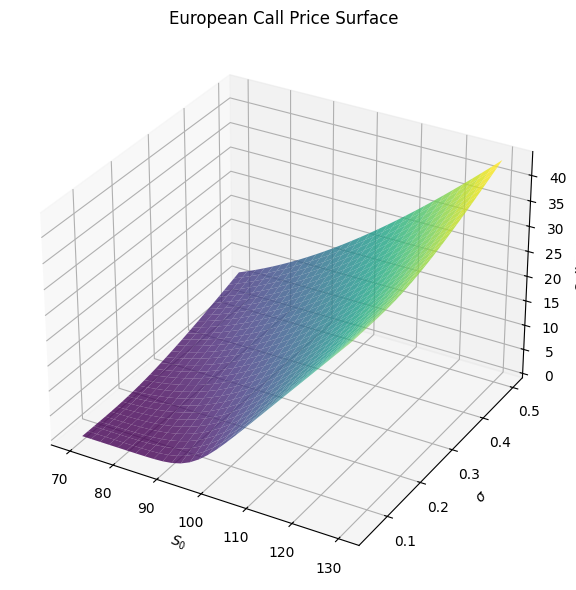

In [8]:
S_vals = np.linspace(70, 130, 30)
sigma_vals = np.linspace(0.05, 0.5, 30)
S_grid, sigma_grid = np.meshgrid(S_vals, sigma_vals)

# Compute call prices over the grid (analytical for speed)
call_surface = np.vectorize(bs_call)(S_grid, K, r, T, sigma_grid)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, sigma_grid, call_surface, cmap='viridis', alpha=0.8)
ax.set_xlabel('$S_0$')
ax.set_ylabel(r'$\sigma$')
ax.set_zlabel('Call Price')
ax.set_title('European Call Price Surface')
plt.tight_layout()
plt.show()

## Summary

The Feynman-Kac formula transforms the Black-Scholes PDE into a simple expectation:

$$V = e^{-rT}\,\mathbb{E}[\text{payoff}(S_T)]$$

This gives us a universal Monte Carlo engine — we just plug in different payoff functions:

| Payoff | Formula | Closed-form? |
|--------|---------|:------------:|
| Vanilla call | $\max(S_T - K, 0)$ | Yes |
| Vanilla put | $\max(K - S_T, 0)$ | Yes |
| Digital call | $\mathbf{1}_{S_T > K}$ | Yes |
| Straddle | $\left|S_T - K\right|$ | Yes (call + put) |
| Power option | $\max(S_T^2/S_0 - K, 0)$ | Difficult |
| Capped call | $\min(\max(S_T - K, 0), C)$ | Possible |

The MC approach converges at rate $O(1/\sqrt{N})$ regardless of payoff complexity. In Chapter 5, we will extend to **American options**, where early exercise requires the Longstaff-Schwartz algorithm instead of the direct Feynman-Kac formula.